<a href="https://colab.research.google.com/github/b-314/menu-vision/blob/main/bank_fraud_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Account Fraud — Predictive Analysis

## 1. Imports and Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/data 110 final project/Bank_Account_Fraud.csv")
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(55290, 32)

## 2. Data Cleaning

Several columns encode missing values as -1 (documented in the data dictionary). We replace these with NaN so they are excluded from statistics and imputed properly later. intended_balcon_amount uses negatives for missing.

In [ ]:
MISSING_COLS = [
    'prev_address_months_count', 'current_address_months_count',
    'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w',
]

df_clean = df.copy()
for col in MISSING_COLS:
    df_clean[col] = df_clean[col].replace(-1, np.nan)
df_clean['intended_balcon_amount'] = df_clean['intended_balcon_amount'].apply(
    lambda x: np.nan if x < 0 else x
)

missing = df_clean.isnull().sum()
print('Missing values after sentinel replacement:')
print(missing[missing > 0])

Missing values after sentinel replacement:
prev_address_months_count       41010
current_address_months_count      238
intended_balcon_amount          40416
bank_months_count               10061
session_length_in_minutes          88
device_distinct_emails_8w          16
dtype: int64


### Summary Statistics by Fraud Status

In [ ]:
numeric_cols = [
    'income', 'customer_age', 'credit_risk_score',
    'velocity_6h', 'velocity_24h', 'velocity_4w',
    'zip_count_4w', 'proposed_credit_limit', 'bank_months_count',
]

summary = df_clean.groupby('fraud_bool')[numeric_cols].mean().T
summary.columns = ['Legitimate (0)', 'Fraud (1)']
summary['Difference (Fraud - Legit)'] = summary['Fraud (1)'] - summary['Legitimate (0)']
print('Mean Values: Fraud vs. Legitimate')
display(summary)

Mean Values: Fraud vs. Legitimate


,Legitimate (0),Fraud (1),Difference (Fraud - Legit)
income,0.5448,0.6866,0.1418
customer_age,33.4317,40.8586,7.4270
credit_risk_score,116.4721,177.5904,61.1182
velocity_6h,7451.1108,5183.9134,-2267.1973
velocity_24h,5883.9415,4613.1388,-1270.8027
velocity_4w,6190.3319,4755.8442,-1434.4877
zip_count_4w,2165.5640,1622.3115,-543.2524
proposed_credit_limit,586.6971,833.9868,247.2897
bank_months_count,14.2957,17.3623,3.0666


## 3. Visualizations

### Visualization 1 — Histograms: Key Numeric Features by Fraud Status

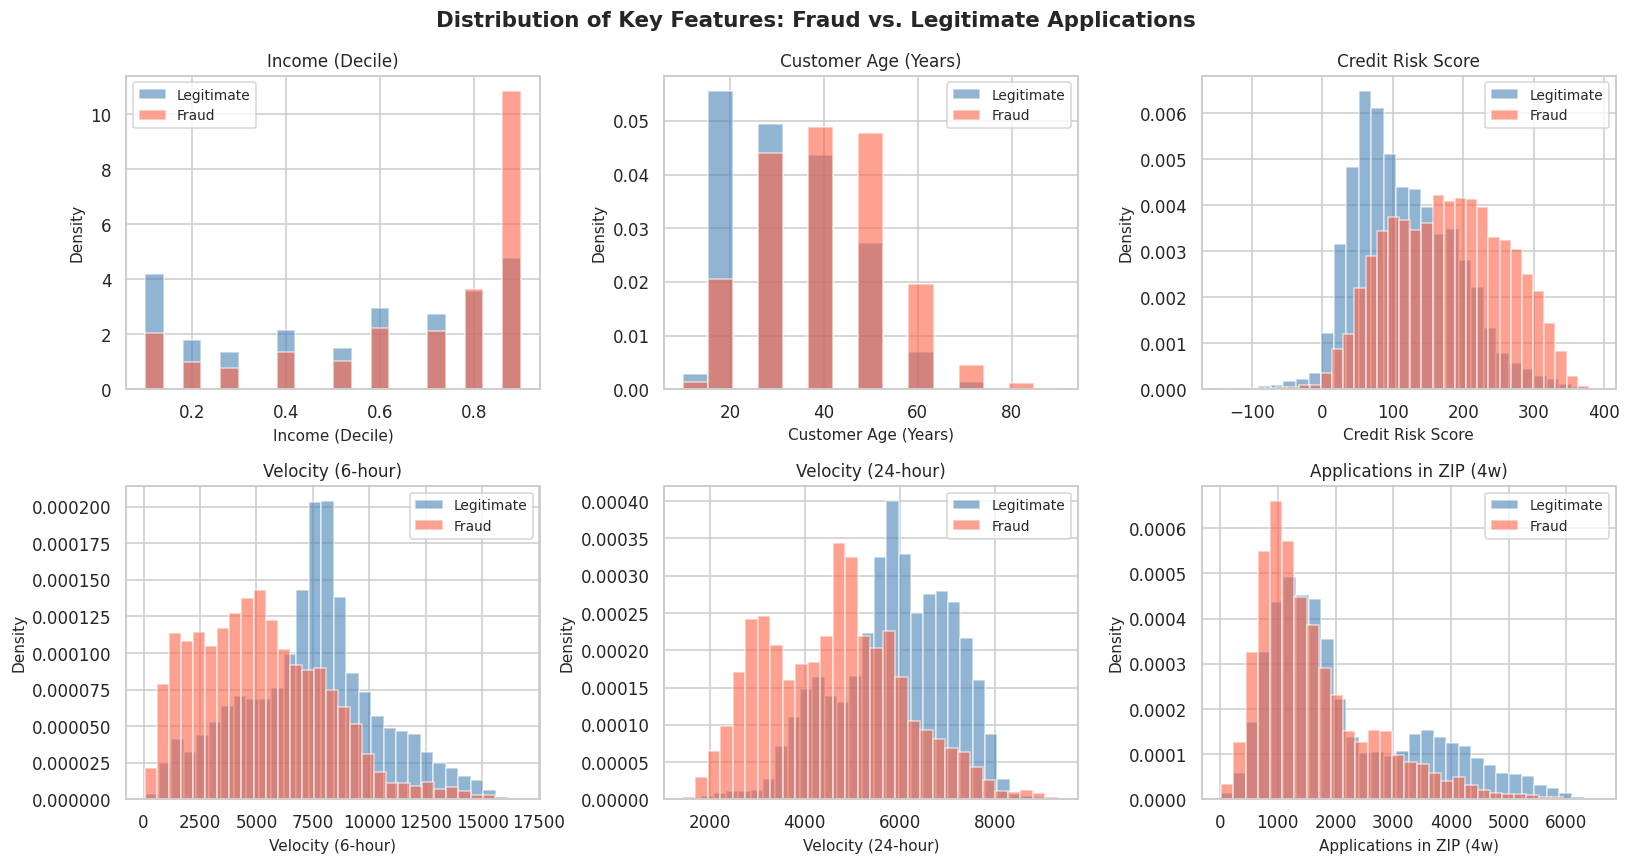

In [ ]:
fraud = df_clean[df_clean['fraud_bool'] == 1]
legit = df_clean[df_clean['fraud_bool'] == 0]

hist_vars = [
    ('income',            'Income (Decile)',          20),
    ('customer_age',      'Customer Age (Years)',      15),
    ('credit_risk_score', 'Credit Risk Score',         30),
    ('velocity_6h',       'Velocity (6-hour)',         30),
    ('velocity_24h',      'Velocity (24-hour)',        30),
    ('zip_count_4w',      'Applications in ZIP (4w)',  30),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Key Features: Fraud vs. Legitimate Applications',
             fontsize=14, fontweight='bold')

for ax, (col, label, bins) in zip(axes.flat, hist_vars):
    ax.hist(legit[col].dropna(), bins=bins, alpha=0.6, color='steelblue', label='Legitimate', density=True)
    ax.hist(fraud[col].dropna(), bins=bins, alpha=0.6, color='tomato',    label='Fraud',      density=True)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz1_histograms.png', bbox_inches='tight')
plt.show()

**Interpretation: (Juslyn) Fraudulent applications are heavily concentrated in highest income when it's above 0.8 deciles. In addition, most fraud occurs between the ages of 20 and 60, but more prevalent in the 30's and 50's as there is a spike.Fraudulent applicants tend to have a higher credit score risk since its graph is shifted to the right, showing a range around 200-350. Legitimate applicants have a smaller cluster that has a lower range of 50-150 with peaks. In terms of velocity, the velocity for both the 6-hour and 24-hour period has a higher density towards the end of the scale for the fraudulent applicants, which could be categorized as them trying to fly under the radar and not appear frequently active. For the applications in ZIP, Fraud is more common in zip codes with a lower volume of applicants, under 2000, and as the number of applications increase, the proportion between legitimate and fraud applications drops.**

### Visualization 2 — Scatter Plot: Customer Age vs. Credit Risk Score

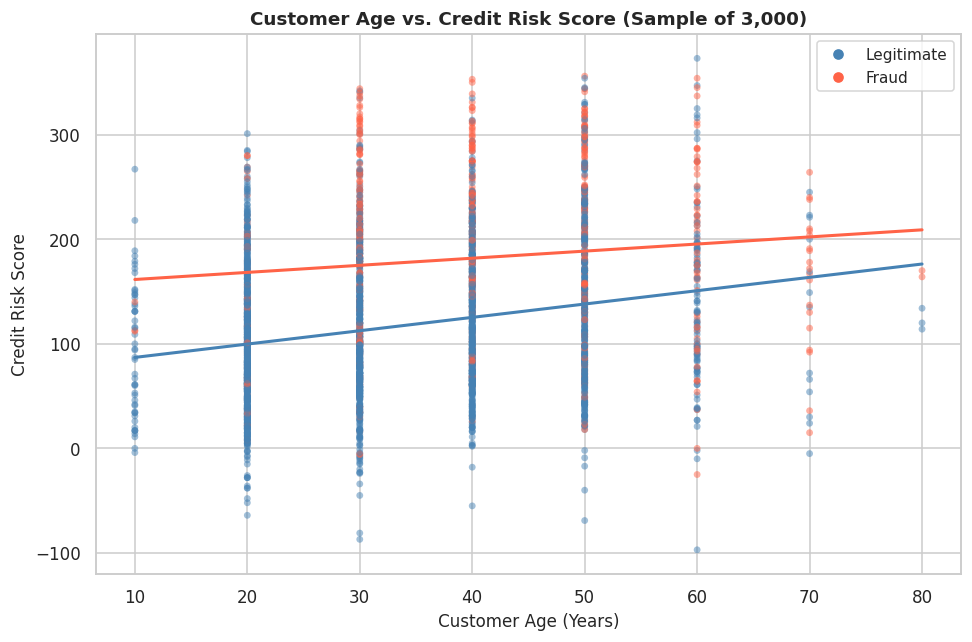

In [ ]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(df_clean.index, size=3000, replace=False)
samp = df_clean.loc[sample_idx]

fig, ax = plt.subplots(figsize=(9, 6))
colors = samp['fraud_bool'].map({0: 'steelblue', 1: 'tomato'})
ax.scatter(samp['customer_age'], samp['credit_risk_score'],
           c=colors, alpha=0.5, edgecolors='none', s=20)

for val, color, label in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
    sub = samp[samp['fraud_bool'] == val][['customer_age', 'credit_risk_score']].dropna()
    m, b_coef = np.polyfit(sub['customer_age'], sub['credit_risk_score'], 1)
    x_line = np.linspace(sub['customer_age'].min(), sub['customer_age'].max(), 100)
    ax.plot(x_line, m * x_line + b_coef, color=color, linewidth=2,
            label=f'{label} (slope={m:.1f})')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Legitimate'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    markersize=8, label='Fraud'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel('Customer Age (Years)', fontsize=11)
ax.set_ylabel('Credit Risk Score', fontsize=11)
ax.set_title('Customer Age vs. Credit Risk Score (Sample of 3,000)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('viz2_scatter_age_credit.png', bbox_inches='tight')
plt.show()

**Interpretation:(Juslyn) The scatter plot displays a correlation between customer age and credit score risk. Looking at the graph, both legitimate and fradulent applications have. a positive slope, showing that as customers increase in age, the credit score risk increases as well. The red dots displayed for fraud are very prevalent at a higher credit score riskks, clustered around 200-300. Overall, this visualization suggests that while age is positively correlated with credit risk, fraudulent behavior is more strongly associated with higher credit risk scores. This insight supports the idea that credit risk score could be an important feature in fraud detection models, especially when combined with other behavioral or demographic variables.**

### Visualization 3 — Categorical Features: Fraud Rate by Category

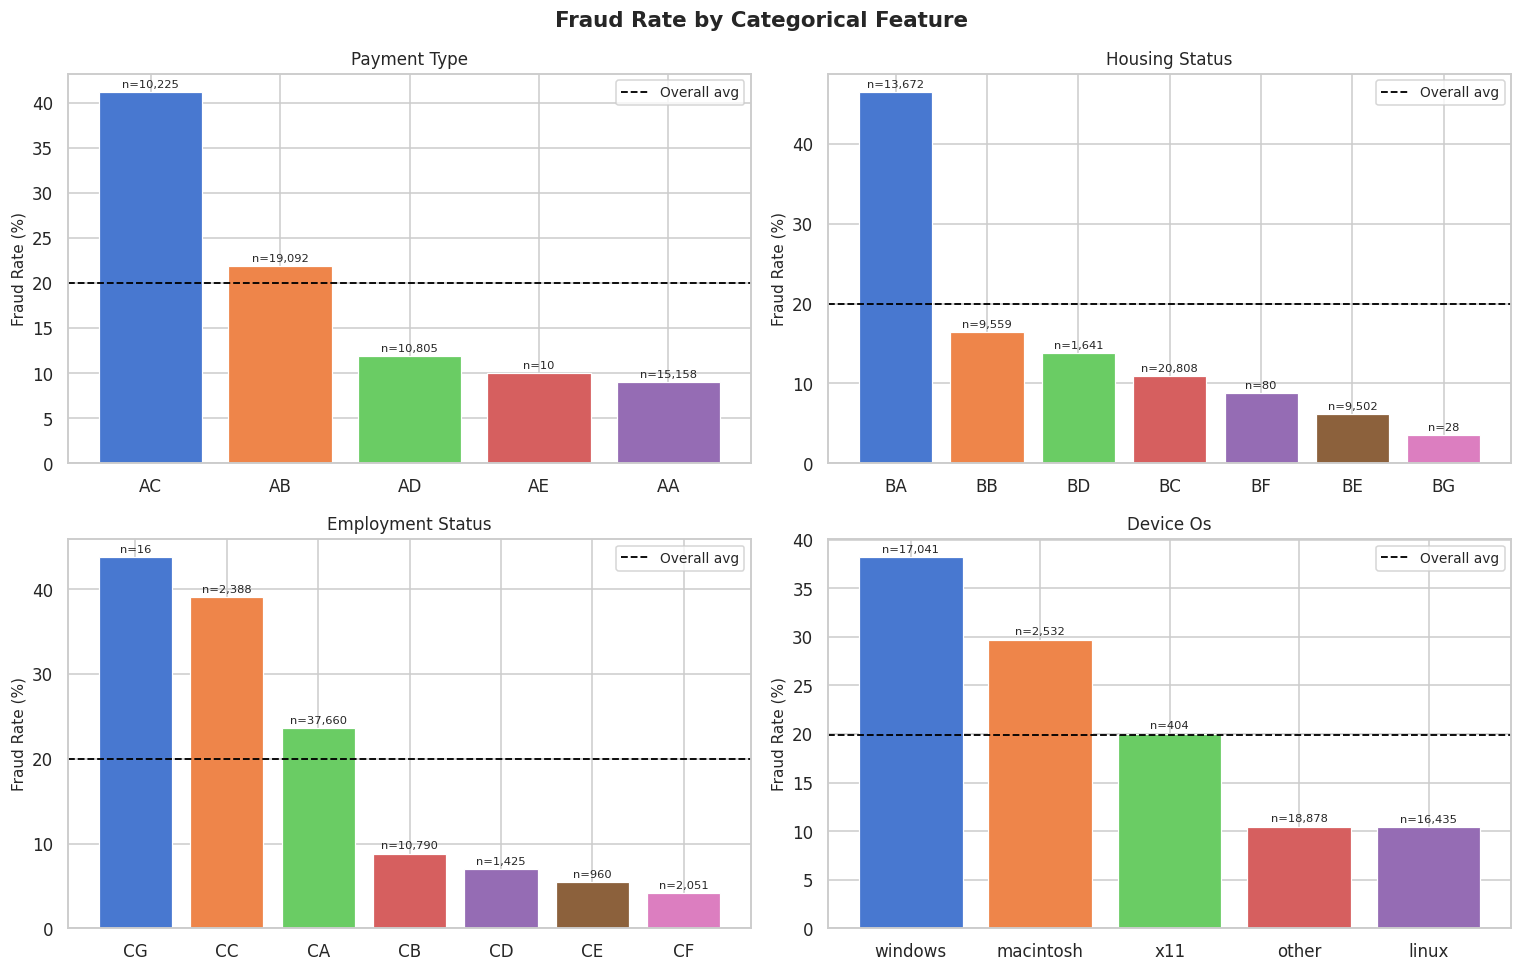

In [ ]:
cat_cols = ['payment_type', 'housing_status', 'employment_status', 'device_os']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Fraud Rate by Categorical Feature', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, cat_cols):
    rates  = df_clean.groupby(col)['fraud_bool'].mean().sort_values(ascending=False)
    counts = df_clean[col].value_counts()
    bars = ax.bar(rates.index, rates.values * 100,
                  color=sns.color_palette('muted', len(rates)),
                  edgecolor='white', linewidth=0.8)
    ax.axhline(df_clean['fraud_bool'].mean() * 100, color='black',
               linestyle='--', linewidth=1.2, label='Overall avg')
    ax.set_ylabel('Fraud Rate (%)', fontsize=10)
    ax.set_title(col.replace('_',' ').title(), fontsize=11)
    ax.legend(fontsize=9)
    for bar, cat in zip(bars, rates.index):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'n={counts[cat]:,}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('viz3_categorical_fraud_rates.png', bbox_inches='tight')
plt.show()

**Interpretation(Caroline): These bar graphs show which categorical features make one more susceptible to bank fraud. These features include Payment Type, Housing Status, Employment Status, and Device Operative Systems. Those who use Windows have a much higher fraud rate than most other operative systems. Macintosh also has a higher fraud rate, making these two systems the least secure in terms of possible fraud. Different employment status categories are also indicators of fraud risk. Those with employment status CG, CC, and CA have fraud rates over 20%, meaning they are at higher risk for fraud. Housing status also plays a role in fraud risk, but it does not have as big of a range as the others. It appears that those with housing status of BA are the most susceptible to fraud in terms of housing status. The fraud rate from the data set showed BA housing status to have a fraud rate of almost 50%. Payment type is also a crucial factor within detecting one's fraud risk. Those who use payment type AC are at the highest risk, with AB also being higher than average.**

### Visualization 4 — Correlation Heatmap

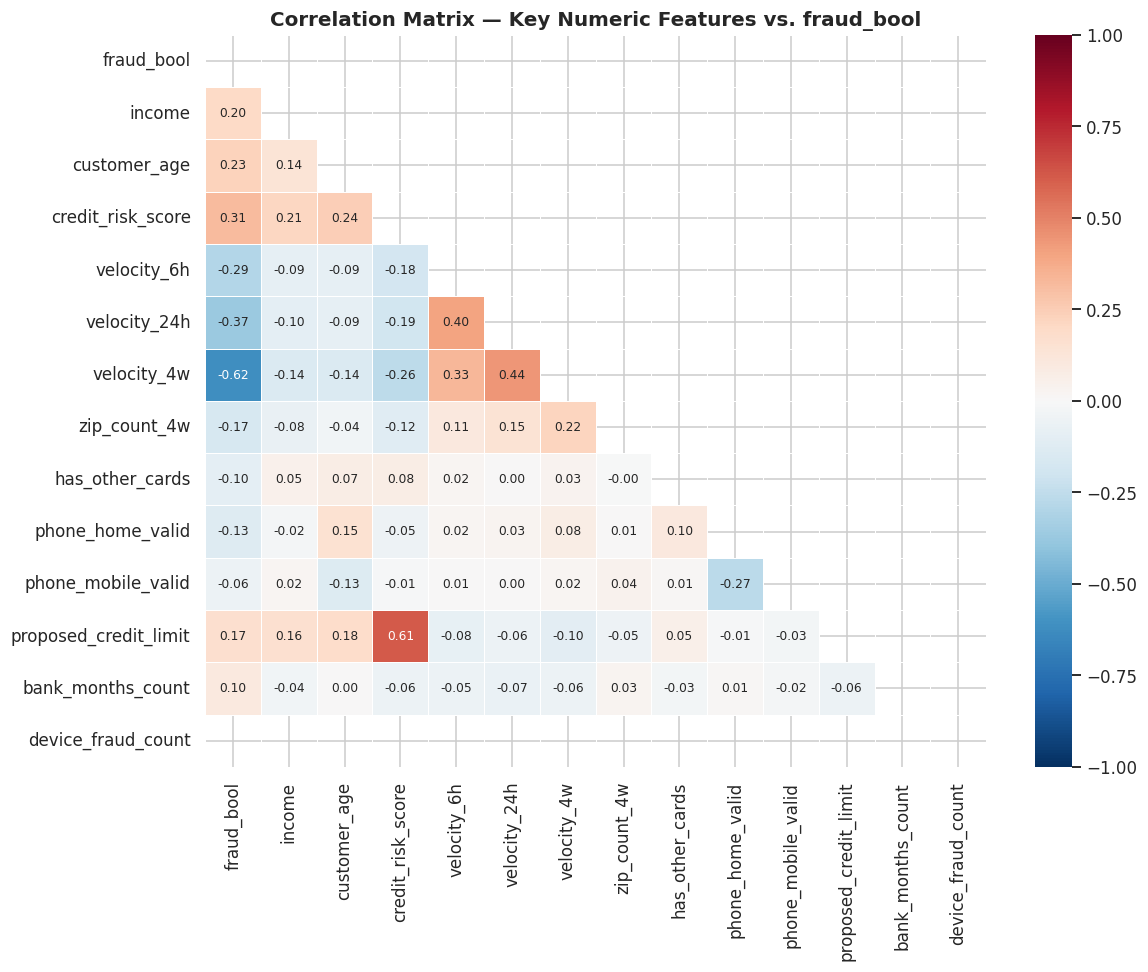

In [ ]:
corr_cols = [
    'fraud_bool', 'income', 'customer_age', 'credit_risk_score',
    'velocity_6h', 'velocity_24h', 'velocity_4w', 'zip_count_4w',
    'has_other_cards', 'phone_home_valid', 'phone_mobile_valid',
    'proposed_credit_limit', 'bank_months_count', 'device_fraud_count'
]

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Numeric Features vs. fraud_bool',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Interpretation(Caroline): This heatmap shows us which factors correlate with each other the most. This information then can tell us which factors could later lead to a higher fraud risk. According to the map, most of the factors used in the dataset are not strongly correlated. However, credit risk score and proposed credit limit stand out as the most correlated factors, scoring 0.61. This means that those with a higher credit risk score most likely have a high proposed credit limit.**

### Visualization 5 — Binary Features: Fraud Rate Comparison

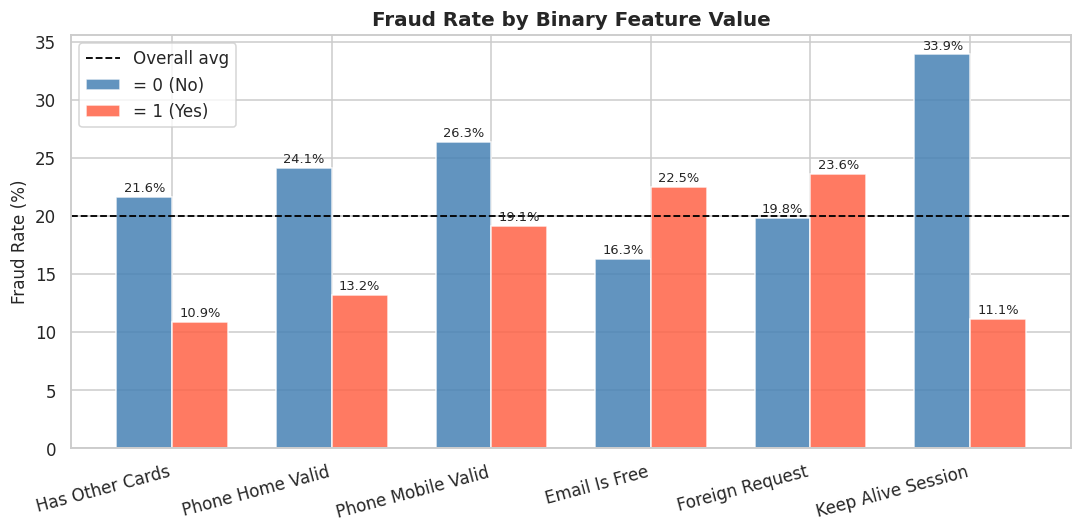

In [ ]:
binary_cols = ['has_other_cards', 'phone_home_valid', 'phone_mobile_valid',
               'email_is_free', 'foreign_request', 'keep_alive_session']
binary_labels = ['Has Other Cards', 'Phone Home Valid', 'Phone Mobile Valid',
                 'Email Is Free', 'Foreign Request', 'Keep Alive Session']

rate_0 = [df_clean[df_clean[c]==0]['fraud_bool'].mean()*100 for c in binary_cols]
rate_1 = [df_clean[df_clean[c]==1]['fraud_bool'].mean()*100 for c in binary_cols]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(binary_labels)); w = 0.35
bars0 = ax.bar(x - w/2, rate_0, width=w, color='steelblue', label='= 0 (No)',  alpha=0.85)
bars1 = ax.bar(x + w/2, rate_1, width=w, color='tomato',    label='= 1 (Yes)', alpha=0.85)
ax.axhline(df_clean['fraud_bool'].mean()*100, color='black',
           linestyle='--', linewidth=1.2, label='Overall avg')
ax.set_xticks(x)
ax.set_xticklabels(binary_labels, rotation=15, ha='right')
ax.set_ylabel('Fraud Rate (%)', fontsize=11)
ax.set_title('Fraud Rate by Binary Feature Value', fontsize=13, fontweight='bold')
ax.legend()
for bar in list(bars0) + list(bars1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.savefig('viz5_binary_fraud_rates.png', bbox_inches='tight')
plt.show()

**Interpretation (Caroline): According to the data set,there are many binary features that can correlate to a higher fraud rate, and therefore a higher fraud risk. The data set showed that applicants who do not have other cards tend to have a higher fraud rate. Additionally, people who's home and mobile phone are not valid are at a higher risk of fraud. People who have a free email or are making the request from outside the country have an above average fraud rate. Those who choose to not keep the session alive have the highest fraud rate by far, landing around 35%. This makes this one of the strongest indicators of fraud risk.**

## 4. Hypothesis Tests

Rather than confirming the obvious (higher credit scores predict higher requested limits), we use the combination of credit_risk_score and proposed_credit_limit to test whether their joint pattern is associated with fraud risk. We run three tests:

1. **Chi-square test** — Is requesting a high credit limit (above median) significantly associated with fraud across the full dataset?
2. **Chi-square test on the suspicious quadrant** — Among applicants with high credit risk scores, does also requesting a high limit significantly elevate fraud risk compared to high-score + low-limit applicants?
3. **Welch t-test** — Do fraudulent applicants request a higher credit limit relative to their credit risk score than legitimate applicants?

In [ ]:
def norm_cdf(x):
    """Abramowitz & Stegun approximation of the standard normal CDF."""
    sign = 1 if x >= 0 else -1
    xabs = abs(x)
    b = [0.2316419, 0.319381530, -0.356563782, 1.781477937, -1.821255978, 1.330274429]
    t_v  = 1.0 / (1.0 + b[0] * xabs)
    poly = b[1]*t_v + b[2]*t_v**2 + b[3]*t_v**3 + b[4]*t_v**4 + b[5]*t_v**5
    cdf  = 1.0 - (1/np.sqrt(2*np.pi)) * np.exp(-xabs**2/2) * poly
    return cdf if sign == 1 else 1 - cdf

pair = df_clean[['credit_risk_score', 'proposed_credit_limit', 'fraud_bool']].dropna().copy()

score_median = pair['credit_risk_score'].median()
limit_median = pair['proposed_credit_limit'].median()

pair['high_score'] = (pair['credit_risk_score'] >= score_median).astype(int)
pair['high_limit'] = (pair['proposed_credit_limit'] > limit_median).astype(int)

# Ratio: requested credit limit per unit of credit risk score
pair['limit_per_score'] = pair['proposed_credit_limit'] / (pair['credit_risk_score'].clip(lower=1))

print(f'Score median : {score_median:.0f}')
print(f'Limit median : ${limit_median:.0f}')
print(f'\nFraud rate by quadrant:')
quad = pair.groupby(['high_score', 'high_limit'])['fraud_bool'].agg(['mean', 'count'])
quad.index = quad.index.map(lambda x: f'score={"high" if x[0] else "low"}, limit={"high" if x[1] else "low"}')
quad.columns = ['Fraud Rate', 'n']
quad['Fraud Rate'] = quad['Fraud Rate'].map('{:.1%}'.format)
display(quad)

Score median : 118
Limit median : $200

Fraud rate by quadrant:


,Fraud Rate,n
"score=low, limit=low",11.0%,23311
"score=low, limit=high",10.3%,4192
"score=high, limit=low",24.2%,7661
"score=high, limit=high",30.7%,20126


### Test 1 — Chi Square
#### Is requesting a higher credit limit associated with fraud?

**H_0:** Whether an applicant requests a high credit limit (above median) is independent of fraud status.  
**H_1:** Requesting a high credit limit is associated with higher fraud rates.

In [ ]:
def chi_square_2x2(a, b, c, d):
    n   = a + b + c + d
    E_a = (a + b) * (a + c) / n
    E_b = (a + b) * (b + d) / n
    E_c = (c + d) * (a + c) / n
    E_d = (c + d) * (b + d) / n
    chi2 = (a-E_a)**2/E_a + (b-E_b)**2/E_b + (c-E_c)**2/E_c + (d-E_d)**2/E_d

    z = np.sqrt(chi2)
    p = 2 * (1 - norm_cdf(z))
    return chi2, p

low_lim_legit  = len(pair[(pair['high_limit']==0) & (pair['fraud_bool']==0)])
low_lim_fraud  = len(pair[(pair['high_limit']==0) & (pair['fraud_bool']==1)])
high_lim_legit = len(pair[(pair['high_limit']==1) & (pair['fraud_bool']==0)])
high_lim_fraud = len(pair[(pair['high_limit']==1) & (pair['fraud_bool']==1)])

chi2_t1, p_t1 = chi_square_2x2(low_lim_legit, low_lim_fraud, high_lim_legit, high_lim_fraud)

fraud_rate_low  = low_lim_fraud  / (low_lim_legit  + low_lim_fraud)
fraud_rate_high = high_lim_fraud / (high_lim_legit + high_lim_fraud)

print('Test 1: Chi-Square — High Credit Limit vs. Fraud')
print(f'  Low limit  (<=median): fraud rate = {fraud_rate_low:.1%}  (n={low_lim_legit+low_lim_fraud:,})')
print(f'  High limit (>median) : fraud rate = {fraud_rate_high:.1%}  (n={high_lim_legit+high_lim_fraud:,})')
print(f'  Chi-square statistic : {chi2_t1:.2f}')
print(f'  p-value              : {p_t1:.2e}')
print()
if p_t1 < 0.05:
    print('  -> Reject H0: requesting a high credit limit is significantly associated with fraud.')
    print(f'     Applicants requesting above-median limits have a {fraud_rate_high - fraud_rate_low:.1%} higher fraud rate.')
else:
    print('  -> Fail to reject H0.')

Test 1: Chi-Square — High Credit Limit vs. Fraud
  Low limit  (<=median): fraud rate = 14.3%  (n=30,972)
  High limit (>median) : fraud rate = 27.2%  (n=24,318)
  Chi-square statistic : 1412.95
  p-value              : 0.00e+00

  -> Reject H0: requesting a high credit limit is significantly associated with fraud.
     Applicants requesting above-median limits have a 12.9% higher fraud rate.


**Interpretation:(Lina)There is a relationship between requesting higher credit limit and fraud. Applicants who are requesting higher credit limits tend to have a higher fraud rate (27.2%) compared to others who are requesting lower limits (14.3%). The p-value is also at 0, meaning that the correlation is very strong. So the null hypothesis will be rejected and it is certain that requesting a high credit limit is associated with fraud.**

### Test 2 — Chi-Square
#### Among high-score applicants, does a high limit request elevate fraud risk?

**H_0:** Among applicants with high credit risk scores, requesting a high vs. low limit is independent of fraud status.  
**H_1:** High-score applicants who also request a high limit have a significantly higher fraud rate.


In [ ]:
high_score_grp = pair[pair['high_score'] == 1]

hs_ll = len(high_score_grp[(high_score_grp['high_limit']==0) & (high_score_grp['fraud_bool']==0)])
hs_lf = len(high_score_grp[(high_score_grp['high_limit']==0) & (high_score_grp['fraud_bool']==1)])
hs_hl = len(high_score_grp[(high_score_grp['high_limit']==1) & (high_score_grp['fraud_bool']==0)])
hs_hf = len(high_score_grp[(high_score_grp['high_limit']==1) & (high_score_grp['fraud_bool']==1)])

chi2_t2, p_t2 = chi_square_2x2(hs_ll, hs_lf, hs_hl, hs_hf)

fr_low_limit  = hs_lf / (hs_ll + hs_lf)
fr_high_limit = hs_hf / (hs_hl + hs_hf)

print('Test 2: Chi-Square — High Score + High Limit vs. Fraud')
print(f'  High score + low limit : fraud rate = {fr_low_limit:.1%}  (n={hs_ll+hs_lf:,})')
print(f'  High score + high limit: fraud rate = {fr_high_limit:.1%}  (n={hs_hl+hs_hf:,})')
print(f'  Chi-square statistic   : {chi2_t2:.2f}')
print(f'  p-value                : {p_t2:.2e}')
print()
if p_t2 < 0.05:
    print('  -> Reject H0: among high-score applicants, requesting a high limit significantly')
    print(f'     elevates fraud risk by {fr_high_limit - fr_low_limit:.1%}.')
else:
    print('  -> Fail to reject H0.')

Test 2: Chi-Square — High Score + High Limit vs. Fraud
  High score + low limit : fraud rate = 24.2%  (n=7,661)
  High score + high limit: fraud rate = 30.7%  (n=20,126)
  Chi-square statistic   : 113.12
  p-value                : 0.00e+00

  -> Reject H0: among high-score applicants, requesting a high limit significantly
     elevates fraud risk by 6.5%.


**Interpretation:(Lina) According to Test 2 there is a correlation between requesting a higher credit limit and fraud among high score applicants. Applicants who are requesting higher credit limits have a higher fraud rate (30.7%) compared to those who request lower limits (24.2%). The p-value is also 0, meaning that the results are correlated. The null hypothesis is rejected again, and it shows that requesting a high credit limit is going to be associated with higher fraud even among high score applicants.**

### Test 3 — Welch t-Test: Do fraudulent applicants request limits that deviate from what their credit score predicts?

We fit a single OLS regression line (proposed_credit_limit ~ credit_risk_score) on the full dataset, then compute each applicant's residual, or how much more or less they requested than the score-based prediction. A positive residual means the applicant requested more than their score would predict.

**H_0:** The mean residual is the same for fraud and legitimate applicants.  
**H_1 (two-tailed):** Fraudulent applicants show a systematically different residual. Their limit requests deviate from what the credit score alone would predict.

In [ ]:
x_all = pair['credit_risk_score'].values.astype(float)
y_all = pair['proposed_credit_limit'].values.astype(float)
xm, ym   = x_all.mean(), y_all.mean()
slope_ols = np.dot(x_all - xm, y_all - ym) / np.dot(x_all - xm, x_all - xm)
int_ols   = ym - slope_ols * xm
pair['residual'] = y_all - (slope_ols * x_all + int_ols)

fraud_resid = pair.loc[pair['fraud_bool']==1, 'residual'].values
legit_resid = pair.loc[pair['fraud_bool']==0, 'residual'].values

n1, n2 = len(fraud_resid), len(legit_resid)
m1, m2 = fraud_resid.mean(), legit_resid.mean()
v1, v2 = np.var(fraud_resid, ddof=1), np.var(legit_resid, ddof=1)
se     = np.sqrt(v1/n1 + v2/n2)
t_stat = (m1 - m2) / se
df_w   = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
p_t3   = 2 * min(norm_cdf(t_stat), 1 - norm_cdf(t_stat))  # two-tailed

print('Test 3: Welch t-Test — Residual Credit Limit Request (vs. Score Prediction)')
print(f'  OLS baseline: credit_limit = {slope_ols:.2f} * credit_risk_score + {int_ols:.2f}')
print(f'  Fraud  mean residual: ${m1:+.2f}  (requests ${abs(m1):.0f} LESS than score predicts)  n={n1:,}')
print(f'  Legit  mean residual: ${m2:+.2f}  (requests ${abs(m2):.0f} MORE than score predicts)  n={n2:,}')
print(f'  t-statistic         : {t_stat:.4f}')
print(f'  Welch df            : {df_w:.1f}')
print(f'  Two-tailed p-value  : {p_t3:.2e}')
print()
if p_t3 < 0.05:
    print('  -> Reject H0: fraudulent applicants request significantly LESS credit than their credit score.')
else:
    print('  -> Fail to reject H0.')

Test 3: Welch t-Test — Residual Credit Limit Request (vs. Score Prediction)
  OLS baseline: credit_limit = 4.57 * credit_risk_score + 48.45
  Fraud  mean residual: $-25.48  (requests $25 LESS than score predicts)  n=11,029
  Legit  mean residual: $+6.35  (requests $6 MORE than score predicts)  n=44,261
  t-statistic         : -6.1109
  Welch df            : 15693.4
  Two-tailed p-value  : 9.94e-10

  -> Reject H0: fraudulent applicants request significantly LESS credit than their credit score.


**Interpretation:(Lina) There is a difference between fraudulent and legitimate applicants in how their requested credit limits compare to what their credit score is predicting. Fraudulent applicants tend to request less than what their score is predicting (25 dollars less), while the legitimate applicants are requesting slightly more (6 dollars more). The p-value is also very small, so there is strong evidence to reject the null hypothesis. Fraudulent applications behave differently from what the credit score alone would suggest.**

## 5. Data Preparation for Modeling

- One-hot encode all categorical variables
- Impute remaining NaN values with column medians
- Standardize features (z-score) using training-set statistics only to prevent data leakage
- 80/20 train-test split via random permutation

In [ ]:
df_model = df_clean.copy()

cat_features = ['payment_type', 'employment_status', 'housing_status', 'device_os', 'source']
df_model = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

feature_cols = [c for c in df_model.columns if c != 'fraud_bool']

for col in feature_cols:
    if df_model[col].isnull().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model[feature_cols].values.astype(float)
y = df_model['fraud_bool'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Any NaN remaining: {np.isnan(X).any()}')
print(f'Fraud rate: {y.mean():.1%}')

Feature matrix shape: (55290, 47)
Any NaN remaining: False
Fraud rate: 19.9%


In [ ]:
rng2  = np.random.default_rng(0)
idx   = rng2.permutation(len(X))
split = int(0.8 * len(X))
X_train, X_test = X[idx[:split]], X[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]

# Standardize using TRAINING statistics only (no leakage)
mean_tr = X_train.mean(axis=0)
std_tr  = X_train.std(axis=0) + 1e-8
X_tr_s  = (X_train - mean_tr) / std_tr
X_te_s  = (X_test  - mean_tr) / std_tr

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train fraud rate: {y_train.mean():.1%}  |  Test fraud rate: {y_test.mean():.1%}')

Train: 44,232  |  Test: 11,058
Train fraud rate: 20.0%  |  Test fraud rate: 19.8%


## 6. Logistic Regression (NumPy — Gradient Descent)

We implement binary logistic regression from scratch. The loss function is binary cross-entropy, minimized via batch gradient descent over 1,000 epochs with learning rate 0.05.

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def logistic_train(X, y, lr=0.05, epochs=1000, print_every=200):
    n, p  = X.shape
    w     = np.zeros(p)
    b     = 0.0
    losses = []
    for epoch in range(1, epochs + 1):
        proba = sigmoid(X @ w + b)
        err   = proba - y
        w    -= lr * (X.T @ err) / n
        b    -= lr * err.mean()
        loss  = -np.mean(y * np.log(proba + 1e-15) + (1 - y) * np.log(1 - proba + 1e-15))
        losses.append(loss)
        if epoch % print_every == 0:
            print(f'  Epoch {epoch:4d}  Cross-entropy loss: {loss:.5f}')
    return w, b, losses

print('Training Logistic Regression — 1,000 epochs, lr=0.05...')
w, b, train_losses = logistic_train(X_tr_s, y_train)

Training Logistic Regression — 1,000 epochs, lr=0.05...
  Epoch  200  Cross-entropy loss: 0.18923
  Epoch  400  Cross-entropy loss: 0.15361
  Epoch  600  Cross-entropy loss: 0.14083
  Epoch  800  Cross-entropy loss: 0.13405
  Epoch 1000  Cross-entropy loss: 0.12972


In [ ]:
def evaluate(y_true, y_pred, label=''):
    TP = int(np.sum((y_pred==1) & (y_true==1)))
    TN = int(np.sum((y_pred==0) & (y_true==0)))
    FP = int(np.sum((y_pred==1) & (y_true==0)))
    FN = int(np.sum((y_pred==0) & (y_true==1)))
    acc  = (TP + TN) / len(y_true)
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    print(f'  {label}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  Confusion: TP={TP:,} | TN={TN:,} | FP={FP:,} | FN={FN:,}')
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

proba_test = sigmoid(X_te_s @ w + b)
print()
m50 = evaluate(y_test, (proba_test >= 0.50).astype(int), 'Threshold = 0.50')
print()
m30 = evaluate(y_test, (proba_test >= 0.30).astype(int), 'Threshold = 0.30')
print()
m20 = evaluate(y_test, (proba_test >= 0.20).astype(int), 'Threshold = 0.20')


  Threshold = 0.50
  Accuracy : 0.9592
  Precision: 0.9812
  Recall   : 0.8096
  F1 Score : 0.8872
  Confusion: TP=1,773 | TN=8,834 | FP=34 | FN=417

  Threshold = 0.30
  Accuracy : 0.9590
  Precision: 0.9182
  Recall   : 0.8708
  F1 Score : 0.8938
  Confusion: TP=1,907 | TN=8,698 | FP=170 | FN=283

  Threshold = 0.20
  Accuracy : 0.9447
  Precision: 0.8330
  Recall   : 0.9018
  F1 Score : 0.8660
  Confusion: TP=1,975 | TN=8,472 | FP=396 | FN=215


### Visualization 6 — Model Metrics at Three Thresholds

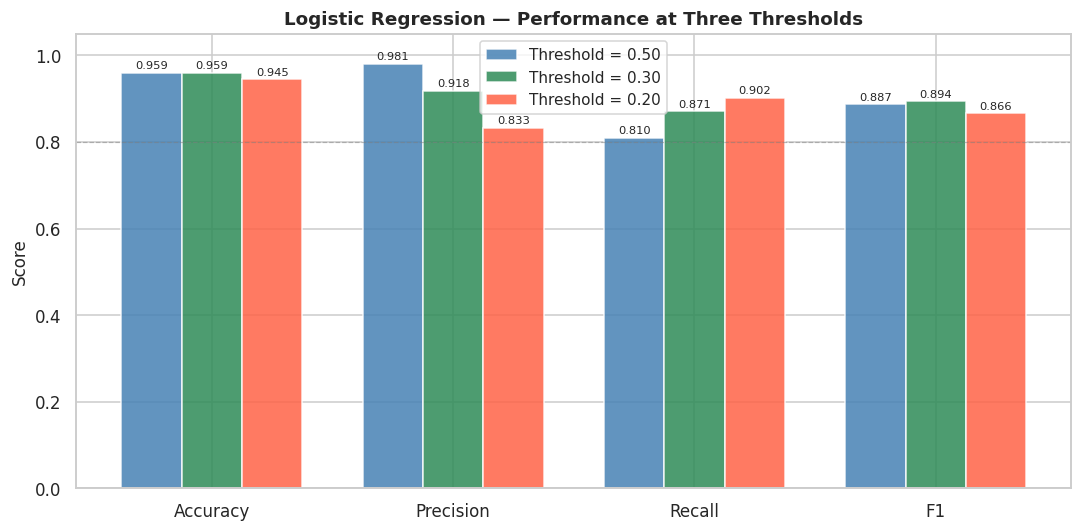

In [ ]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
all_metrics  = [
    ('Threshold = 0.50', m50, 'steelblue'),
    ('Threshold = 0.30', m30, 'seagreen'),
    ('Threshold = 0.20', m20, 'tomato'),
]

x     = np.arange(len(metric_names))
w_bar = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, m, color) in enumerate(all_metrics):
    vals   = [m['accuracy'], m['precision'], m['recall'], m['f1']]
    offset = (i - 1) * w_bar
    bars   = ax.bar(x + offset, vals, width=w_bar, color=color, alpha=0.85, label=label)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Logistic Regression — Performance at Three Thresholds',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.80, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('viz6_model_metrics.png', bbox_inches='tight')
plt.show()

**Interpretation:(Lina) The model is performing well across all the three thresholds, but there are some drawbacks. The 0.50 threshold, has the highest precision (0.981), meaning it is very accurate when predicting fraud cases, but the recall is lower (0.810). As the thresholds decrease to the 0.30 and 0.20, the recall also increases up to 0.902, meaning that the model catches more fraud cases but its precision decreases. Accuracy is staying high across all thresholds, while the F1 score is slightly better at 0.30. Overall, lowering the threshold helps detect more fraud but also increases the amount of false positives.**

### Visualization 7 — Training Loss Curve

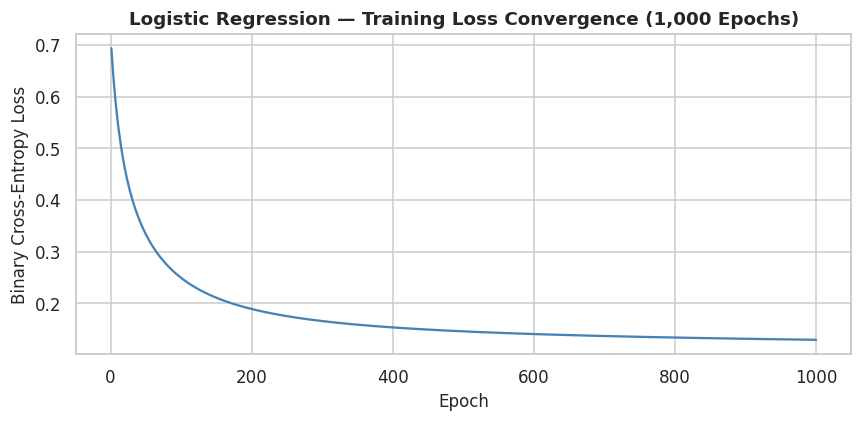

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, color='steelblue', linewidth=1.5)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
ax.set_title('Logistic Regression — Training Loss Convergence (1,000 Epochs)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz7_training_loss.png', bbox_inches='tight')
plt.show()

**Interpretation:(Lina) The training loss curve decreases at the beginning but levels off over time. This shows that the model is learning and improving during its training. After a few hundred epochs, the loss changes very little, which means the model has mostly converged. Overall, the model is stable and does not show any major issues during its training.**

### Visualization 8 — Top Feature Importances (Model Coefficients)

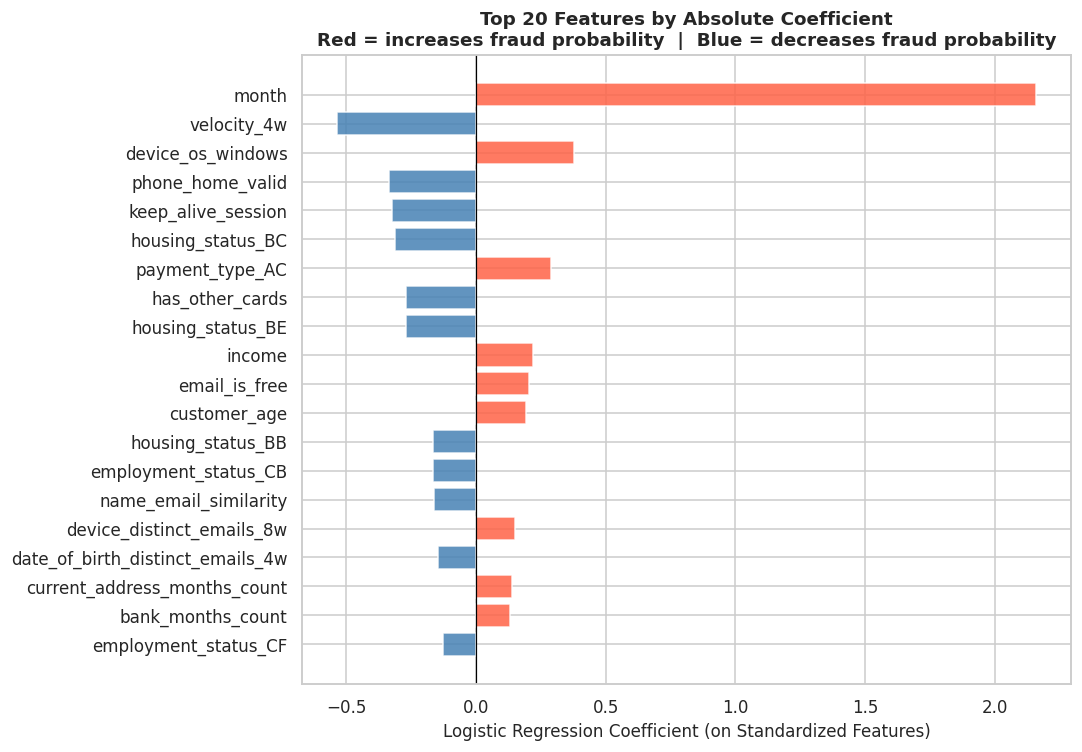

In [ ]:
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': w})
coef_df['Abs'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs', ascending=False).head(20)

colors_coef = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colors_coef, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (on Standardized Features)', fontsize=11)
ax.set_title('Top 20 Features by Absolute Coefficient\n'
             'Red = increases fraud probability  |  Blue = decreases fraud probability',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz8_feature_importance.png', bbox_inches='tight')
plt.show()

**Interpretation(Caroline): Our models helped narrow down which factors decrease or increase applcant's fraud probability. We have concluded that those with a 4-week velocity, valid home phone numbers, other cards, employment statuses of both CF and CB, housing statuses of both BB and BE, emails with distinct date of birth or names similar to their own, and choose to keep the session alive have a decreasing fraud probability. These are all the right things to do to avoid fraud. On the other hand, we found that the higher the income and age of the applicant, the more susceptible they are to fraud. Additionally, the later the month of the application, the higher the fraud risk. We also found that a higher number of distinct emails in the website within the last 8 weeks, as well as a higher number of months in the registered address and the age of the account can increase the chance of fraud. If the applicant uses Windows, has a free email, and uses payment type AC, they are more susceptible to fraud, too. These are things to avoid if you want to lower your fraud risk.**

## 7. Final Model Summary

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (threshold=0.50)',
        'Logistic Regression (threshold=0.30)',
        'Logistic Regression (threshold=0.20)',
    ],
    'Accuracy':  [m50['accuracy'],  m30['accuracy'],  m20['accuracy']],
    'Precision': [m50['precision'], m30['precision'], m20['precision']],
    'Recall':    [m50['recall'],    m30['recall'],    m20['recall']],
    'F1 Score':  [m50['f1'],        m30['f1'],        m20['f1']],
}).set_index('Model')

print('Final Model Performance Comparison')
display(results.style.format('{:.4f}').highlight_max(subset=['Recall'], color='#ba96d4'))

Final Model Performance Comparison


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression (threshold=0.50),0.9592,0.9812,0.8096,0.8872
Logistic Regression (threshold=0.30),0.9590,0.9182,0.8708,0.8938
Logistic Regression (threshold=0.20),0.9447,0.8330,0.9018,0.8660


In [1]:
!git config --global user.email "advika.arun@gmail.com"
!git config --global user.name "advikaarun-star"
